# AlphaGenome Variant Analysis (cohort)

This notebook analyzes AlphaGenome variant scoring results and generates visualizations and summary tables.

## Setup
1. Set the `INPUT_DIR` variable to point to your directory containing AlphaGenome CSV files
2. Set the `OUTPUT_DIR` variable for saving results
3. Run all cells in order

## 1. Configuration

In [1]:
# ============================================
# CONFIGURATION
# ============================================

# Current cohort output directory from 01_alphagenome_analysis notebook.
INPUT_DIR = "../01_alphagenome_analysis/alphagenome_intron6_cohort/csv/"   # Directory containing alphagenome_scores_*.csv files
OUTPUT_DIR = "./plots_patients_cohort"  # Directory for output files

# Pathogenicity thresholds (customized)
THRESHOLD_HIGH = 0.999      # Top 0.1%
THRESHOLD_MODERATE = 0.99   # Top 1%
THRESHOLD_LOW = 0.95        # Top 5%

## 2. Import Libraries

In [2]:
import glob
import os
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from plotnine import *

warnings.filterwarnings('ignore')

# Create output directory if needed
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Input directory: {INPUT_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Input directory: ../01_alphagenome_analysis/alphagenome_intron6_cohort/csv/
Output directory: ./plots_patients_cohort


## 3. Data Loading Function

In [3]:
def load_alphagenome_files(input_dir: str) -> pd.DataFrame:
    """
    Load all AlphaGenome CSV files from a directory and combine them.
    
    Parameters
    ----------
    input_dir : str
        Path to directory containing AlphaGenome CSV files
        
    Returns
    -------
    pd.DataFrame
        Combined dataframe with all variant scores
    """
    file_pattern = os.path.join(input_dir, 'alphagenome_scores_*.csv')
    files = glob.glob(file_pattern)

    # Backward-compatible fallback: old folder name -> current folder name.
    if not files and 'alphagenome_patients_cohort' in input_dir:
        fallback_dir = input_dir.replace('alphagenome_patients_cohort', 'alphagenome_intron6_cohort')
        fallback_pattern = os.path.join(fallback_dir, 'alphagenome_scores_*.csv')
        fallback_files = glob.glob(fallback_pattern)
        if fallback_files:
            print(f"No files in {input_dir}. Using fallback: {fallback_dir}")
            input_dir = fallback_dir
            files = fallback_files

    if not files:
        raise FileNotFoundError(f"No AlphaGenome CSV files found in {input_dir}")
    
    print(f"Found {len(files)} AlphaGenome score files:")
    for f in sorted(files):
        print(f"  - {os.path.basename(f)}")
    
    # Load and combine all files
    dfs = []
    for f in files:
        df = pd.read_csv(f)
        dfs.append(df)
    
    combined_df = pd.concat(dfs, ignore_index=True)
    
    # Clean up - remove unnamed index column if present
    if 'Unnamed: 0' in combined_df.columns:
        combined_df = combined_df.drop(columns=['Unnamed: 0'])
    
    # Data quality checks
    print(f"\n--- Data Quality Check ---")
    print(f"Total rows: {combined_df.shape[0]}")
    print(f"Total columns: {combined_df.shape[1]}")
    
    # Check for duplicate columns
    dup_cols = combined_df.columns[combined_df.columns.duplicated()].tolist()
    if dup_cols:
        print(f"WARNING: Duplicate columns found: {dup_cols}")
        combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()]
    else:
        print("✓ No duplicate columns")
    
    return combined_df

## 4. Pathogenicity Classification Function

In [4]:
def classify_pathogenicity(quantile: float, 
                           threshold_high: float = 0.999,
                           threshold_moderate: float = 0.99,
                           threshold_low: float = 0.95) -> str:
    """
    Classify variant pathogenicity based on quantile score.
    
    Parameters
    ----------
    quantile : float
        AlphaGenome quantile score (0-1)
    threshold_high : float
        Threshold for High Impact classification
    threshold_moderate : float
        Threshold for Moderate Impact classification
    threshold_low : float
        Threshold for Low Impact classification
        
    Returns
    -------
    str
        Impact classification
    """
    if quantile >= threshold_high:
        return 'High Impact'
    elif quantile >= threshold_moderate:
        return 'Moderate Impact'
    elif quantile >= threshold_low:
        return 'Low Impact'
    else:
        return 'No Impact'

## 5. Variant Summary Function

In [5]:
def create_variant_summary(combined_df: pd.DataFrame,
                           threshold_high: float = 0.999,
                           threshold_moderate: float = 0.99,
                           threshold_low: float = 0.95) -> pd.DataFrame:
    """
    Create summary statistics for each variant.
    
    Parameters
    ----------
    combined_df : pd.DataFrame
        Combined AlphaGenome scores dataframe
    threshold_high, threshold_moderate, threshold_low : float
        Classification thresholds
        
    Returns
    -------
    pd.DataFrame
        Summary dataframe with one row per variant
    """
    variant_summary = []
    
    for variant in combined_df['variant_id'].unique():
        var_data = combined_df[combined_df['variant_id'] == variant]
        
        # Extract position and change from variant_id
        parts = variant.split(':')
        position = int(parts[1])
        change = parts[2]
        
        # Get scores by output type
        splice_junction_data = var_data[var_data['output_type'] == 'SPLICE_JUNCTIONS']
        splice_site_data = var_data[var_data['output_type'] == 'SPLICE_SITE_USAGE']
        
        summary = {
            'variant_id': variant,
            'position': position,
            'change': change,
            'n_predictions': len(var_data),
            # Splice junction scores
            'splice_junction_max_raw': splice_junction_data['raw_score'].max() if len(splice_junction_data) > 0 else np.nan,
            'splice_junction_max_quantile': splice_junction_data['quantile_score'].max() if len(splice_junction_data) > 0 else np.nan,
            'splice_junction_mean_raw': splice_junction_data['raw_score'].mean() if len(splice_junction_data) > 0 else np.nan,
            'splice_junction_mean_quantile': splice_junction_data['quantile_score'].mean() if len(splice_junction_data) > 0 else np.nan,
            # Splice site usage scores
            'splice_site_max_raw': splice_site_data['raw_score'].max() if len(splice_site_data) > 0 else np.nan,
            'splice_site_max_quantile': splice_site_data['quantile_score'].max() if len(splice_site_data) > 0 else np.nan,
            'splice_site_mean_raw': splice_site_data['raw_score'].mean() if len(splice_site_data) > 0 else np.nan,
            'splice_site_mean_quantile': splice_site_data['quantile_score'].mean() if len(splice_site_data) > 0 else np.nan,
        }
        
        # Overall max scores
        summary['overall_max_raw'] = var_data['raw_score'].max()
        summary['overall_max_quantile'] = var_data['quantile_score'].max()
        summary['overall_mean_quantile'] = var_data['quantile_score'].mean()
        
        variant_summary.append(summary)
    
    summary_df = pd.DataFrame(variant_summary)
    summary_df = summary_df.sort_values('overall_max_quantile', ascending=False)
    
    # Add classifications
    summary_df['short_variant'] = summary_df['variant_id'].apply(
        lambda x: x.split(':')[1] + ':' + x.split(':')[2]
    )
    # Classification is based on the SPLICE_SITE_USAGE quantile score only.
    # If a variant has no SPLICE_SITE_USAGE prediction, it is labelled as 'Not Evaluated'.
    summary_df['impact_class'] = summary_df['splice_site_max_quantile'].apply(
        lambda x: classify_pathogenicity(x, threshold_high, threshold_moderate, threshold_low)
        if pd.notna(x) else 'Not Evaluated'
    )
    
    return summary_df

## 6. Visualization Functions

### 6.2 Scores Heatmap

In [6]:
def plot_scores_heatmap(
    combined_df: pd.DataFrame,
    summary_df: pd.DataFrame,
    output_dir: str = None,
    filename_stem: str = 'variant_scores_heatmap',
):
    """
    Create heatmap of scores by variant and output type.

    Parameters
    ----------
    combined_df : pd.DataFrame
        Combined AlphaGenome scores dataframe
    summary_df : pd.DataFrame
        Variant summary dataframe
    output_dir : str, optional
        Output directory for saving plots
    filename_stem : str, optional
        Basename for saved PNG/SVG (without extension)
    """
    # Get max quantile score for each variant and output type
    heatmap_data = combined_df.groupby(['variant_id', 'output_type'])['quantile_score'].max().reset_index()
    heatmap_data['short_variant'] = heatmap_data['variant_id'].apply(
        lambda x: x.split(':')[1] + ':' + x.split(':')[2]
    )

    # Pivot for heatmap
    heatmap_pivot = heatmap_data.pivot(index='short_variant', columns='output_type', values='quantile_score')

    # Sort by overall impact
    order = summary_df.sort_values('overall_max_quantile', ascending=False)['short_variant'].tolist()
    heatmap_pivot = heatmap_pivot.reindex(order)

    fig, ax = plt.subplots(figsize=(5.6, max(3, 0.45 * len(heatmap_pivot) + 1.5)))

    sns.heatmap(
        heatmap_pivot,
        annot=True,
        fmt='.4f',
        cmap='RdYlGn_r',
        vmin=0.9,
        vmax=1.0,
        linewidths=0.5,
        cbar_kws={'label': 'Quantile Score'},
        ax=ax
    )

    ax.set_title('AlphaGenome scores by variant and prediction type', fontsize=10)
    ax.set_xlabel('Prediction Type', fontsize=8)
    ax.set_ylabel('', fontsize=10)

    plt.tight_layout()

    if output_dir:
        plt.savefig(os.path.join(output_dir, f'{filename_stem}.png'), dpi=300, bbox_inches='tight')
        print(f'Saved: {filename_stem}.png/svg')

    plt.show()

## 7. Summary Table Function

In [7]:
def save_summary_table(summary_df: pd.DataFrame, output_dir: str = None) -> pd.DataFrame:
    """
    Save the variant summary table to CSV.
    
    Parameters
    ----------
    summary_df : pd.DataFrame
        Variant summary dataframe
    output_dir : str, optional
        Output directory for saving the table
        
    Returns
    -------
    pd.DataFrame
        Formatted summary table
    """
    final_summary = summary_df[['variant_id', 'position', 'change', 'impact_class',
                                'overall_max_quantile', 'overall_max_raw', 'overall_mean_quantile',
                                'splice_junction_max_quantile', 'splice_site_max_quantile',
                                'n_predictions']].copy()
    
    final_summary = final_summary.sort_values('overall_max_quantile', ascending=False)
    final_summary.columns = ['Variant ID', 'Position', 'Change', 'Impact Classification',
                             'Max Quantile Score', 'Max Raw Score', 'Mean Quantile Score',
                             'Splice Junction Max', 'Splice Site Max', 'N Predictions']
    
    # Round numeric columns
    numeric_cols = ['Max Quantile Score', 'Max Raw Score', 'Mean Quantile Score',
                    'Splice Junction Max', 'Splice Site Max']
    for col in numeric_cols:
        final_summary[col] = final_summary[col].round(6)
    
    if output_dir:
        output_path = os.path.join(output_dir, 'variant_pathogenicity_summary.csv')
        final_summary.to_csv(output_path, index=False)
        print(f"Saved: variant_pathogenicity_summary.csv")
    
    return final_summary

## 8. Classification Summary Function

In [8]:
def print_classification_summary(summary_df: pd.DataFrame,
                                  threshold_high: float = 0.999,
                                  threshold_moderate: float = 0.99,
                                  threshold_low: float = 0.95) -> None:
    """
    Print a summary of variant classifications.
    
    Parameters
    ----------
    summary_df : pd.DataFrame
        Variant summary dataframe
    threshold_high, threshold_moderate, threshold_low : float
        Classification thresholds
    """
    print("\n" + "=" * 50)
    print("PATHOGENICITY CLASSIFICATION SUMMARY")
    print("=" * 50)
    print(f"\nClassification thresholds (based on quantile scores):")
    print(f"  - High Impact: quantile >= {threshold_high} (top {(1-threshold_high)*100:.1f}%)")
    print(f"  - Moderate Impact: quantile >= {threshold_moderate} (top {(1-threshold_moderate)*100:.0f}%)")
    print(f"  - Low Impact: quantile >= {threshold_low} (top {(1-threshold_low)*100:.0f}%)")
    print(f"  - No Impact: quantile < {threshold_low}\n")
    
    for impact in ['High Impact', 'Moderate Impact', 'Low Impact', 'No Impact']:
        variants_in_class = summary_df[summary_df['impact_class'] == impact]['short_variant'].tolist()
        print(f"{impact}: {len(variants_in_class)} variants")
        if variants_in_class:
            for v in variants_in_class:
                print(f"    - {v}")
    print()

---
## 9. Run Analysis

Execute the cells below to run the complete analysis pipeline.

### 9.1 Load Data

In [9]:
# Load all AlphaGenome files
combined_df = load_alphagenome_files(INPUT_DIR)

# Display basic info
print(f"\nGene: {combined_df['gene_name'].unique()[0] if 'gene_name' in combined_df.columns else 'Unknown'}")
print(f"Total variants: {combined_df['variant_id'].nunique()}")
print(f"Output types: {combined_df['output_type'].unique().tolist()}")

Found 19 AlphaGenome score files:
  - alphagenome_scores_g.108570605G>T.csv
  - alphagenome_scores_g.108570657C>G.csv
  - alphagenome_scores_g.108570657C>T.csv
  - alphagenome_scores_g.108570658TTTCT>T.csv
  - alphagenome_scores_g.108570661C>A.csv
  - alphagenome_scores_g.108570661C>G.csv
  - alphagenome_scores_g.108570664T>A.csv
  - alphagenome_scores_g.108570690C>G.csv
  - alphagenome_scores_g.108570694G>A.csv
  - alphagenome_scores_g.108570697G>A.csv
  - alphagenome_scores_g.108570699G>A.csv
  - alphagenome_scores_g.108570705G>A.csv
  - alphagenome_scores_g.108570705G>C.csv
  - alphagenome_scores_g.108570706G>T.csv
  - alphagenome_scores_g.108570726C>T.csv
  - alphagenome_scores_g.108570734T>C.csv
  - alphagenome_scores_g.108570753A>G.csv
  - alphagenome_scores_g.108570768T>A.csv
  - alphagenome_scores_g.108570775T>C.csv

--- Data Quality Check ---
Total rows: 148
Total columns: 21
✓ No duplicate columns

Gene: COL4A5
Total variants: 19
Output types: ['SPLICE_JUNCTIONS', 'SPLICE_SIT

### 9.2 Create Summary

In [10]:
# Create variant summary with classifications
summary_df = create_variant_summary(
    combined_df,
    threshold_high=THRESHOLD_HIGH,
    threshold_moderate=THRESHOLD_MODERATE,
    threshold_low=THRESHOLD_LOW
)

# Print classification summary
print_classification_summary(summary_df, THRESHOLD_HIGH, THRESHOLD_MODERATE, THRESHOLD_LOW)


PATHOGENICITY CLASSIFICATION SUMMARY

Classification thresholds (based on quantile scores):
  - High Impact: quantile >= 0.999 (top 0.1%)
  - Moderate Impact: quantile >= 0.99 (top 1%)
  - Low Impact: quantile >= 0.95 (top 5%)
  - No Impact: quantile < 0.95

High Impact: 6 variants
    - 108570775:T>C
    - 108570768:T>A
    - 108570705:G>C
    - 108570705:G>A
    - 108570657:C>G
    - 108570734:T>C
Moderate Impact: 5 variants
    - 108570605:G>T
    - 108570694:G>A
    - 108570658:TTTCT>T
    - 108570753:A>G
    - 108570706:G>T
Low Impact: 2 variants
    - 108570661:C>G
    - 108570697:G>A
No Impact: 6 variants
    - 108570690:C>G
    - 108570699:G>A
    - 108570661:C>A
    - 108570657:C>T
    - 108570664:T>A
    - 108570726:C>T



### 9.3 Generate Visualizations

Saved: variant_scores_heatmap.png/svg


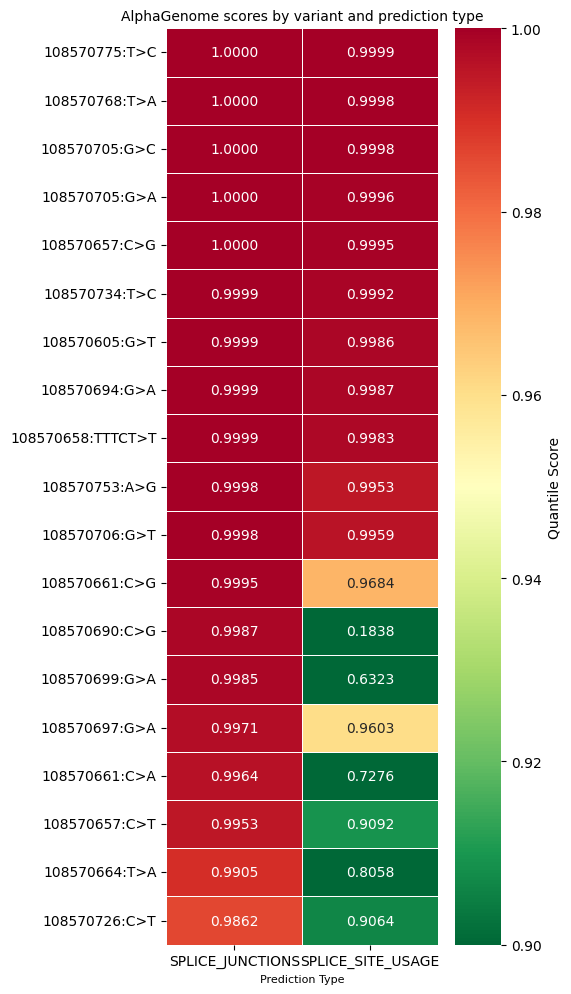

In [11]:
# Plot 2: Scores heatmap
plot_scores_heatmap(combined_df, summary_df, OUTPUT_DIR)

### 9.3b Scores heatmap for selected patient variants

Heatmap restricted to four cohort variants of interest:
`g.108570699G>A`, `g.108570657C>G`, `g.108570705G>A`, `g.108570734T>C`.

Found 8 / 8 selected variants
Matched: ['108570705:G>C', '108570705:G>A', '108570657:C>G', '108570734:T>C', '108570753:A>G', '108570661:C>G', '108570699:G>A', '108570657:C>T']
Saved: variant_scores_heatmap_selected.png/svg


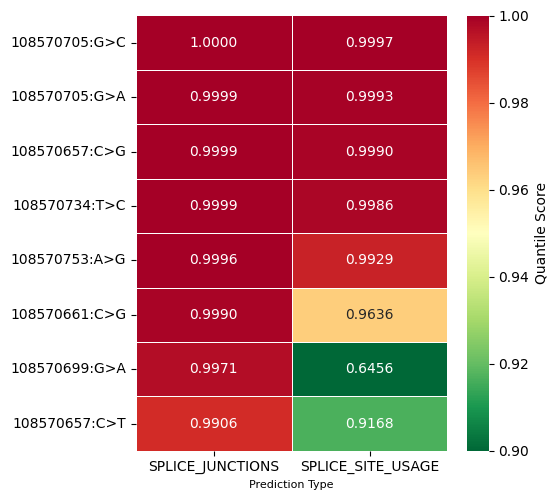

In [24]:
# Selected cohort variants for focused scores heatmap (HGVS-like g. notation)
SELECTED_VARIANTS = [
    "g.108570753A>G",
    "g.108570699G>A",
    "g.108570657C>T",
    "g.108570657C>G",
    "g.108570661C>G",
    "g.108570705G>A",
    "g.108570705G>C",
    "g.108570734T>C"
]

def g_to_variant_id(g_id: str, chrom: str = 'chrX') -> str:
    """Convert g.108570699G>A to chrX:108570699:G>A."""
    body = g_id[2:] if g_id.startswith('g.') else g_id
    for i, ch in enumerate(body):
        if ch in 'ACGT' and '>' in body[i:]:
            return f'{chrom}:{body[:i]}:{body[i:]}'
    raise ValueError(f'Cannot parse variant id: {g_id}')

selected_ids = [g_to_variant_id(v) for v in SELECTED_VARIANTS]

summary_selected = summary_df[summary_df['variant_id'].isin(selected_ids)].copy()
combined_selected = combined_df[combined_df['variant_id'].isin(selected_ids)].copy()

found = set(summary_selected['variant_id'])
missing = [v for v, vid in zip(SELECTED_VARIANTS, selected_ids) if vid not in found]
print(f'Found {len(summary_selected)} / {len(SELECTED_VARIANTS)} selected variants')
print('Matched:', summary_selected['short_variant'].tolist())
if missing:
    print(f'Missing from cohort data: {missing}')

if summary_selected.empty:
    raise ValueError('None of the selected variants were found in summary_df.')

plot_scores_heatmap(
    combined_selected,
    summary_selected,
    OUTPUT_DIR,
    filename_stem='variant_scores_heatmap_selected',
)

### 9.4 Save Summary Table

In [12]:
# Save and display summary table
final_summary = save_summary_table(summary_df, OUTPUT_DIR)

print("\nFinal Summary Table:")
display(final_summary)

Saved: variant_pathogenicity_summary.csv

Final Summary Table:


,Variant ID,Position,Change,Impact Classification,Max Quantile Score,Max Raw Score,Mean Quantile Score,Splice Junction Max,Splice Site Max,N Predictions
6,chrX:108570775:T>C,108570775,T>C,High Impact,0.999990,3.628906,0.999040,0.999990,0.999942,8
18,chrX:108570768:T>A,108570768,T>A,High Impact,0.999982,2.996094,0.999895,0.999982,0.999846,4
2,chrX:108570705:G>C,108570705,G>C,High Impact,0.999978,2.810547,0.999901,0.999978,0.999817,6
0,chrX:108570705:G>A,108570705,G>A,High Impact,0.999960,2.304688,0.999789,0.999960,0.999558,6
11,chrX:108570657:C>G,108570657,C>G,High Impact,0.999956,2.236328,0.998197,0.999956,0.999459,8
4,chrX:108570734:T>C,108570734,T>C,High Impact,0.999946,2.091797,0.999615,0.999946,0.999160,6
1,chrX:108570605:G>T,108570605,G>T,Moderate Impact,0.999922,1.819336,0.999383,0.999922,0.998604,6
7,chrX:108570694:G>A,108570694,G>A,Moderate Impact,0.999874,1.502930,0.999384,0.999874,0.998696,6
14,chrX:108570658:TTTCT>T,108570658,TTTCT>T,Moderate Impact,0.999865,1.467773,0.999239,0.999865,0.998347,6
8,chrX:108570753:A>G,108570753,A>G,Moderate Impact,0.999817,1.276367,0.997871,0.999817,0.995289,6


---
## 10. Analysis Complete

All outputs have been saved to the output directory:
- `variant_pathogenicity_summary.csv` - Summary table
- `variant_scores_heatmap.png/svg` - Heatmap
- `variant_genomic_positions.png/svg` - Position plot
- `variant_score_distributions.png/svg` - Distribution plots

In [13]:
# ============================================
# Separate chunk: AlphaGenome merged splicing score and ranking
# Formula (recommended):
# max(SPLICE_SITES) + max(SPLICE_SITE_USAGE) + max(SPLICE_JUNCTIONS) / 5
# ============================================

required_outputs = ['SPLICE_SITES', 'SPLICE_SITE_USAGE', 'SPLICE_JUNCTIONS']
available_outputs = set(combined_df['output_type'].unique())
missing_outputs = [o for o in required_outputs if o not in available_outputs]
if missing_outputs:
    print(f"Warning: missing output_type rows in combined_df: {missing_outputs}. Using 0 for missing components.")

# Per variant + output type max quantile
max_q = (
    combined_df.groupby(['variant_id', 'output_type'])['quantile_score']
    .max()
    .unstack(fill_value=np.nan)
    .reset_index()
)

# Ensure expected columns exist so merged score is always computable.
for col in required_outputs:
    if col not in max_q.columns:
        max_q[col] = 0.0

max_q['alphagenome_splicing_merged'] = (
    max_q['SPLICE_SITES'].fillna(0)
    + max_q['SPLICE_SITE_USAGE'].fillna(0)
    + (max_q['SPLICE_JUNCTIONS'].fillna(0) / 5.0)
)

# Merge back to summary_df (safe on re-runs)
summary_df = summary_df.drop(
    columns=['alphagenome_splicing_merged', 'alphagenome_splicing_rank'],
    errors='ignore'
)
summary_df = summary_df.merge(
    max_q[['variant_id', 'alphagenome_splicing_merged']],
    on='variant_id',
    how='left'
)

summary_df['alphagenome_splicing_rank'] = (
    summary_df['alphagenome_splicing_merged']
    .rank(method='min', ascending=False)
    .astype('Int64')
)

summary_df_splicing_ranked = (
    summary_df
    .sort_values('alphagenome_splicing_merged', ascending=False)
    .reset_index(drop=True)
)

summary_df_splicing_ranked[['short_variant', 'alphagenome_splicing_merged', 'alphagenome_splicing_rank']].head(20)

,short_variant,alphagenome_splicing_merged,alphagenome_splicing_rank
0,108570775:T>C,1.199940,1
1,108570768:T>A,1.199842,2
2,108570705:G>C,1.199813,3
3,108570705:G>A,1.199550,4
4,108570657:C>G,1.199450,5
5,108570734:T>C,1.199149,6
6,108570694:G>A,1.198670,7
7,108570605:G>T,1.198589,8
8,108570658:TTTCT>T,1.198320,9
9,108570706:G>T,1.195845,10
